# Classical sentiment model development

Objective: compare TRAIN-fitted TF-IDF representations and classical classifiers on the official TweetEval VALIDATION split. Macro-F1 is primary because TRAIN is imbalanced (negative 7,093; neutral 20,673; positive 17,849). TEST remains locked; this notebook never loads TEST labels or predictions. Dataset provenance and data-quality evidence are in the data-foundation reports.

TF-IDF is term frequency times inverse document frequency: it weights a term within a post and downweights terms common across many posts. For *not good*, unigrams are *not* and *good*, while the bigram *not good* retains the phrase. Character n-grams can capture contraction fragments, repeated letters and punctuation. The word token pattern keeps contractions such as *don't* together. No vocabulary or IDF was fitted on VALIDATION.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'config.py').is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from src.features import make_features, WORD_TOKEN_PATTERN
from src.evaluation import select_winner
from src.config import LABELS
comparison = pd.read_csv(root / 'reports' / 'model_comparison.csv')
metrics = json.loads((root / 'reports' / 'model_metrics.json').read_text(encoding='utf-8'))
display(comparison[['experiment_id','feature','model','validation_accuracy','validation_macro_f1','fit_seconds']])

,experiment_id,feature,model,validation_accuracy,validation_macro_f1,fit_seconds
0,exp04,combined,logistic_regression,0.7000,0.657962,29.4336
1,exp07,combined,linear_svm,0.6830,0.653641,8.1167
2,exp03,character,logistic_regression,0.6900,0.646293,11.5338
3,exp06,character,linear_svm,0.6705,0.638214,6.2422
4,exp02,word_bigram,logistic_regression,0.6810,0.636720,4.9016
5,exp05,word_bigram,linear_svm,0.6680,0.633748,1.2824
6,exp01,word_unigram,logistic_regression,0.6730,0.622972,1.6237
7,exp08,word_bigram,naive_bayes,0.6260,0.459243,0.0854
8,exp09,word_bigram,random_forest,0.5405,0.365064,1.1416


## Controlled experiments

Nine full-TRAIN runs cover word unigrams, word unigrams+bigrams, character 3–5 grams and combined word+character TF-IDF. The algorithms are Logistic Regression, LinearSVC, MultinomialNB and a bounded Random Forest. The same official TRAIN and VALIDATION rows are used throughout. Word trigrams and exhaustive search are deferred to focused tuning because the current matrix already tests the main representation differences with manageable memory.

TRAIN fits vectorizers and classifiers; VALIDATION is only transformed and scored. The ranked table and JSON below were produced by the executable pipeline, not recomputed from TEST.

In [2]:
from src.models import EXPERIMENTS
display(pd.DataFrame([vars(e) for e in EXPERIMENTS]))
display({'winner': metrics['winner']['experiment_id'],
         'macro_f1': metrics['winner']['validation_macro_f1'],
         'accuracy': metrics['winner']['validation_accuracy']})
display({'word_pattern': WORD_TOKEN_PATTERN,
         'tokenization_demo': __import__('re').findall(WORD_TOKEN_PATTERN, "don't can't isn't won't not good")})

,id,feature,model
0,exp01,word_unigram,logistic_regression
1,exp02,word_bigram,logistic_regression
2,exp03,character,logistic_regression
3,exp04,combined,logistic_regression
4,exp05,word_bigram,linear_svm
5,exp06,character,linear_svm
6,exp07,combined,linear_svm
7,exp08,word_bigram,naive_bayes
8,exp09,word_bigram,random_forest


{'winner': 'exp04', 'macro_f1': 0.6579620027888405, 'accuracy': 0.7}

{'word_pattern': "(?u)\\b\\w+(?:['’]\\w+)*\\b",
 'tokenization_demo': ["don't", "can't", "isn't", "won't", 'not', 'good']}

## Validation figures

Confusion rows are true labels, columns are predictions, ordered negative, neutral, positive. Only distinct leading candidates get confusion figures.

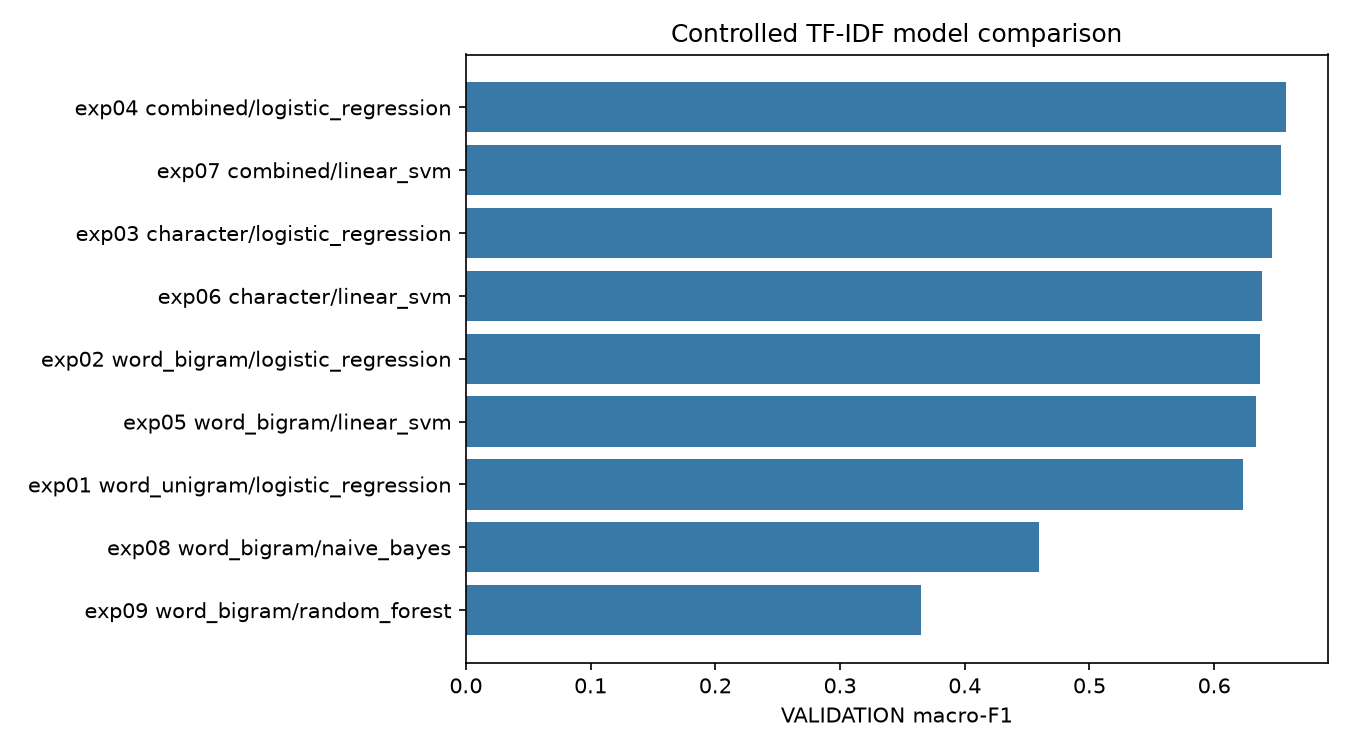

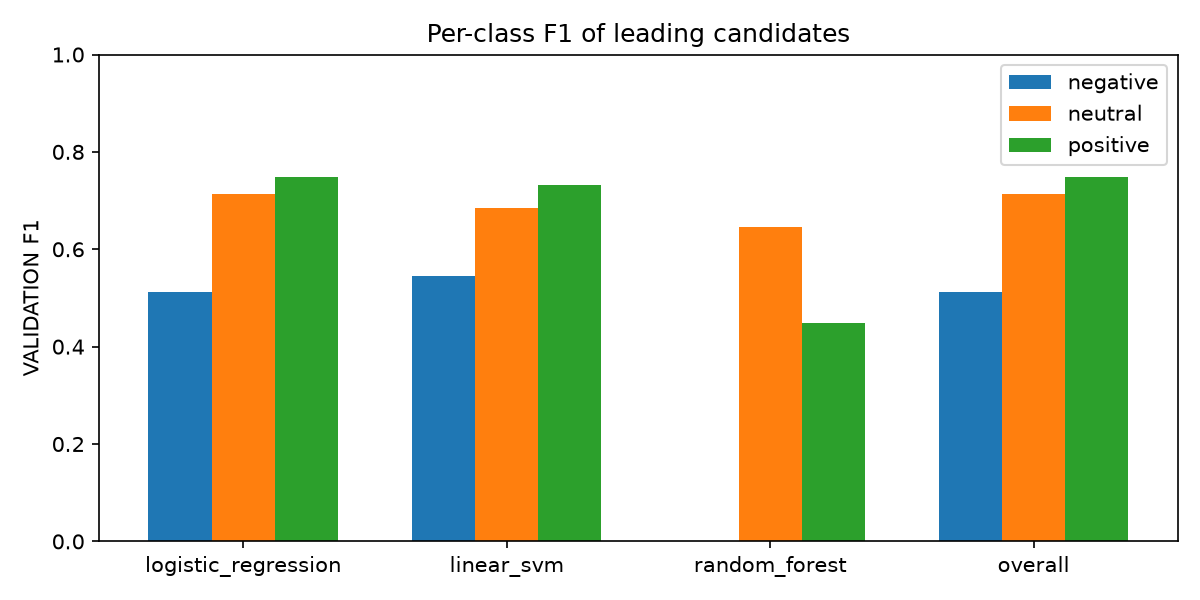

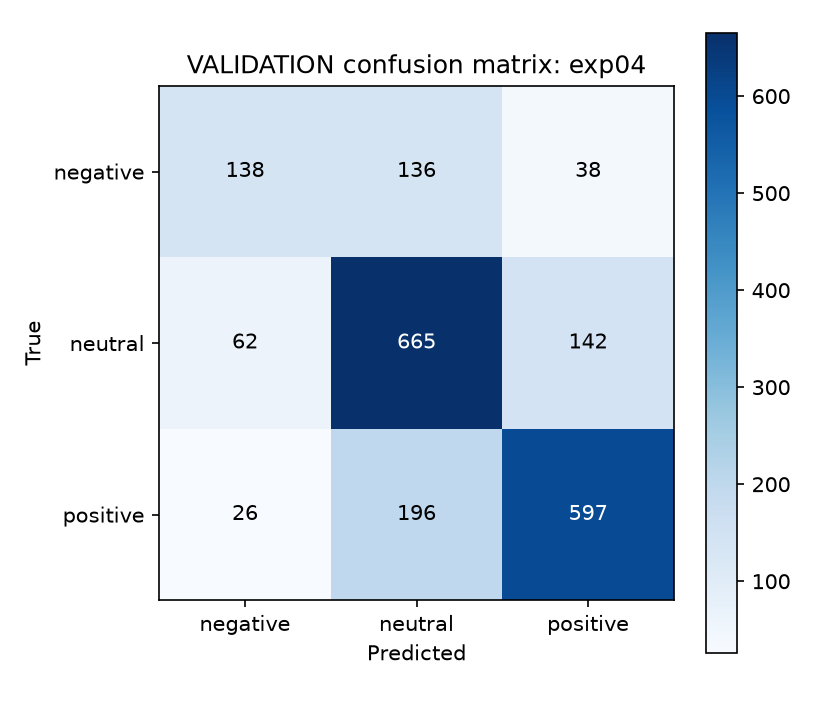

{'classes': ('negative', 'neutral', 'positive'),
 'winner_confusion': [[138, 136, 38], [62, 665, 142], [26, 196, 597]]}

In [3]:
figures = root / 'reports' / 'figures' / 'modeling'
display(Image(filename=str(figures / 'validation_macro_f1.png')))
display(Image(filename=str(figures / 'validation_per_class_f1.png')))
winner_id = metrics['winner']['experiment_id']
display(Image(filename=str(figures / f'validation_confusion_{winner_id}.png')))
display({'classes': LABELS,
         'winner_confusion': metrics['diagnostics'][winner_id]['confusion_matrix']})

## Validation errors and TRAIN-learned features

Small, ordered validation error samples indicate hypotheses, not generalizable causes. Linear coefficient rankings use TRAIN-fitted weights; they do not prove causation. No TEST examples are inspected.

In [4]:
display(Markdown((root / 'reports' / 'error_analysis.md').read_text(encoding='utf-8')))
for label, features in metrics['linear_features'][winner_id].items():
    display({label: [item['feature'] for item in features[:10]]})

# Finalist VALIDATION errors

Rows are true labels and columns predictions in negative, neutral, positive order. Cue associations are descriptive, not causal. TEST is locked.

## logistic_regression

Total errors: 615.
Confusion matrix: [[210, 72, 30], [139, 577, 153], [57, 164, 598]].

| Cue | Rows | Errors | Error rate |
|---|---:|---:|---:|
| negation | 330 | 123 | 0.373 |
| contraction | 767 | 256 | 0.334 |
| emoticon | 52 | 11 | 0.212 |
| punctuation | 619 | 184 | 0.297 |
| short_5_words | 4 | 0 | 0.000 |

## linear_svm

Total errors: 605.
Confusion matrix: [[187, 93, 32], [109, 612, 148], [47, 176, 596]].

| Cue | Rows | Errors | Error rate |
|---|---:|---:|---:|
| negation | 330 | 123 | 0.373 |
| contraction | 767 | 245 | 0.319 |
| emoticon | 52 | 10 | 0.192 |
| punctuation | 619 | 185 | 0.299 |
| short_5_words | 4 | 0 | 0.000 |

## Off-diagonal comparison

| True → predicted | Logistic Regression | LinearSVC |
|---|---:|---:|
| negative → neutral | 72 | 93 |
| negative → positive | 30 | 32 |
| neutral → negative | 139 | 109 |
| neutral → positive | 153 | 148 |
| positive → negative | 57 | 47 |
| positive → neutral | 164 | 176 |

LR catches more negative posts (210 vs 187 true negatives in the negative class row) but also predicts negative more often for neutral posts (139 vs 109). LinearSVC handles the neutral class more accurately. Cue-specific error rates are close and remain descriptive.
Cue groups overlap and have different denominators. Short context, negation, contractions, emoticons and punctuation do not establish causes of error.


{'negative': ['character__ :(',
  'character__:( ',
  'character__uck',
  'word__sad',
  'word__not',
  'word__worst',
  'character__ :( ',
  'word__fuck',
  'word__no',
  'word__ass']}

{'neutral': ['word__do you',
  'word__last day',
  'character__... ',
  'word__bad blood',
  'word__are you',
  'word__this saturday',
  'word__is there',
  'word__what time',
  'word__never know',
  'word__park for']}

{'positive': ["word__can't wait",
  'word__happy',
  'word__good',
  'character__ :)',
  'word__great',
  'word__best',
  'character__:) ',
  'character__!! ',
  'word__love',
  'character__e! ']}

## Baseline candidate before focused tuning

The winning artifact is a VALIDATION-SELECTED CANDIDATE, not a final test-evaluated model. It is persisted as a fitted sklearn Pipeline and its reloaded VALIDATION predictions were checked for exact equality. The bounded Random Forest remains a full-TRAIN baseline; the report records its runtime and weakness on the minority negative class. The focused TRAIN-CV tuning and frozen development candidate appear below. Final TEST evaluation is a separate future task. Historical English tweets, sarcasm, context loss and brand-domain shift remain limitations.

In [5]:
metadata = json.loads((root / 'models' / 'candidates' / 'best_candidate_metadata.json').read_text(encoding='utf-8'))
display(metadata)
assert metadata['reload_predictions_match']
assert 'test_accuracy' not in json.dumps(metrics).lower()

{'status': 'VALIDATION-SELECTED CANDIDATE — NOT FINAL TEST-EVALUATED MODEL',
 'experiment_id': 'exp04',
 'feature': 'combined',
 'model': 'logistic_regression',
 'validation_macro_f1': 0.6579620027888405,
 'validation_accuracy': 0.7,
 'artifact_sha256': '01522167d0d857890cca736d23d6a06f7230551243405d72242d4257893f92b1',
 'artifact_bytes': 4329464,
 'reload_predictions_match': True}

## Corrected escaped punctuation

The source contains literal escaped punctuation in TRAIN and VALIDATION, notably the strings for a comma and curly apostrophe. The preprocessing step now maps only known punctuation escapes before NFC normalization. Existing Unicode, emoji, and unrelated backslashes are preserved. The full before/after baseline comparison is below; TEST content was not explored.

In [6]:
impact = json.loads((root / 'reports' / 'preprocessing_impact.json').read_text(encoding='utf-8'))
display({'affected_rows': impact['affected_raw_rows'],
         'learned_features': impact['learned_features']})
display(pd.DataFrame(impact['after'])[['experiment_id','old_macro_f1','new_macro_f1','delta_macro_f1','new_accuracy']])

{'affected_rows': {'train': 5111, 'validation': 206},
 'learned_features': {'artifact_count': 0,
  'artifact_examples': [],
  'contractions': {"don't": True, "can't wait": True, "isn't": True}}}

,experiment_id,old_macro_f1,new_macro_f1,delta_macro_f1,new_accuracy
0,exp04,0.664563,0.657962,-0.006601,0.7000
1,exp07,0.663119,0.653641,-0.009479,0.6830
2,exp03,0.650029,0.646293,-0.003736,0.6900
3,exp06,0.639250,0.638214,-0.001036,0.6705
4,exp02,0.636299,0.636720,0.000420,0.6810
5,exp05,0.636237,0.633748,-0.002489,0.6680
6,exp01,0.623554,0.622972,-0.000582,0.6730
7,exp08,0.462672,0.459243,-0.003429,0.6260
8,exp09,0.351950,0.365064,0.013113,0.5405


## Focused TRAIN-only cross-validation

The corrected baseline retains combined TF-IDF Logistic Regression and LinearSVC as the two leading linear candidates. Each uses three stratified TRAIN folds, seed 42, and macro-F1 scoring. A sklearn Pipeline includes both FeatureUnion and classifier, so vocabulary and IDF are refitted within each fold. VALIDATION is excluded from the grid search; TEST is locked. Three folds and serial execution contain memory and runtime for sparse matrices with over 200,000 columns. The staged search covers five C values and two class weights per model, then five controlled feature settings near the best classifier configuration.

In [7]:
tuning = json.loads((root / 'reports' / 'tuning_metrics.json').read_text(encoding='utf-8'))
search = pd.read_csv(root / 'reports' / 'tuning_results.csv')
display(tuning['cv'])
display(search.sort_values(['model','stage','rank_within_stage']).groupby(['model','stage']).head(3)[['model','stage','params','mean_cv_macro_f1','std_cv_macro_f1','mean_fit_seconds']])

{'type': 'StratifiedKFold',
 'n_splits': 3,
 'shuffle': True,
 'random_state': 42,
 'scoring': 'f1_macro',
 'rows': 'TRAIN only',
 'feature_fitting': 'inside each Pipeline fold',
 'configurations': 30}

,model,stage,params,mean_cv_macro_f1,std_cv_macro_f1,mean_fit_seconds
16,linear_svm,classifier,"{""classifier__C"": 0.25, ""classifier__class_wei...",0.651738,0.001646,4.188013
18,linear_svm,classifier,"{""classifier__C"": 0.5, ""classifier__class_weig...",0.644005,0.001284,5.017996
15,linear_svm,classifier,"{""classifier__C"": 0.25, ""classifier__class_wei...",0.636099,0.001151,3.983085
25,linear_svm,features,"{""classifier__C"": 0.25, ""classifier__class_wei...",0.651738,0.001646,4.154539
27,linear_svm,features,"{""classifier__C"": 0.25, ""classifier__class_wei...",0.651228,0.001954,4.245030
26,linear_svm,features,"{""classifier__C"": 0.25, ""classifier__class_wei...",0.651154,0.001676,4.068974
5,logistic_regression,classifier,"{""classifier__C"": 1.0, ""classifier__class_weig...",0.654432,0.001950,17.266205
3,logistic_regression,classifier,"{""classifier__C"": 0.5, ""classifier__class_weig...",0.652467,0.002492,13.547233
7,logistic_regression,classifier,"{""classifier__C"": 2.0, ""classifier__class_weig...",0.651932,0.001518,20.842116
12,logistic_regression,features,"{""classifier__C"": 1.0, ""classifier__class_weig...",0.654462,0.002082,27.850746


## Final VALIDATION checkpoint and uncertainty

Both finalists were fitted on all TRAIN after their CV configurations were fixed. They were then evaluated once on VALIDATION. A paired bootstrap resamples the same validation rows for both predictions and measures the macro-F1 difference. It describes sensitivity, not formal proof or external generalization.

In [8]:
display(Markdown((root / 'reports' / 'tuning_summary.md').read_text(encoding='utf-8')))
display(Markdown((root / 'reports' / 'model_uncertainty.md').read_text(encoding='utf-8')))

# Focused TRAIN-only tuning

3-fold stratified CV (shuffle, seed 42), macro-F1 scoring. Three folds limit runtime and memory for 216,107-dimensional combined sparse features. TF-IDF and IDF are fitted inside each training fold by the sklearn Pipeline. VALIDATION is excluded from the search; TEST has no predictive use.

30 configurations: 10 classifier settings and 5 focused feature settings per model, each run on 3 folds. CV executes serially to limit memory duplication.

## TRAIN CV winners

- logistic_regression: mean macro-F1 0.6545 ± 0.0021; parameters {'classifier__C': 1.0, 'classifier__class_weight': 'balanced', 'features__transformer_weights': {'character': 1.25, 'word': 1.0}}.
- linear_svm: mean macro-F1 0.6517 ± 0.0016; parameters {'classifier__C': 0.25, 'classifier__class_weight': 'balanced'}.

## VALIDATION checkpoint

| Model | Accuracy | Macro precision | Macro recall | Macro-F1 | Negative F1 | Neutral F1 | Positive F1 | Fit s | Predict s |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| logistic_regression | 0.6925 | 0.6642 | 0.6891 | 0.6728 | 0.5850 | 0.6861 | 0.7475 | 31.2 | 0.480 |
| linear_svm | 0.6975 | 0.6693 | 0.6771 | 0.6726 | 0.5710 | 0.6994 | 0.7473 | 16.9 | 0.508 |

Selected: **logistic_regression** by VALIDATION macro-F1, considering CV stability, negative F1 and runtime as secondary evidence.
This is a frozen development candidate; TEST has not been evaluated. The paired bootstrap interval in model_uncertainty.md describes remaining selection uncertainty.
Full parameters, scores, per-class metrics and versions are in tuning_metrics.json and frozen_candidate_metadata.json.


# Paired VALIDATION uncertainty

LR minus LinearSVC macro-F1: +0.0003. Paired row-bootstrap percentile 95% interval: [-0.0117, +0.0128]. Fraction of 2000 seeded draws favoring LR: 0.517.

Each resample draws the same VALIDATION row indices for both fixed finalist predictions. This describes sampling sensitivity on this holdout, not formal proof, independent external validation or a correction for development selection. An interval crossing zero means the difference is too small to distinguish confidently by this diagnostic.


## Errors, confidence, and frozen development candidate

Error cues are descriptive. Logistic Regression's maximum probability and LinearSVC's top-versus-second decision margin have different scales. The selected candidate is frozen with its preprocessing and feature configuration, validation scores, artifact checksum and exact reload-prediction check. TEST has not been evaluated.

In [9]:
display(Markdown((root / 'reports' / 'error_analysis.md').read_text(encoding='utf-8')))
display(Markdown((root / 'reports' / 'model_confidence.md').read_text(encoding='utf-8')))
frozen = json.loads((root / 'models' / 'candidates' / 'frozen_candidate_metadata.json').read_text(encoding='utf-8'))
display({'status':frozen['status'], 'selected_model':frozen['selected_model'],
         'artifact_sha256':frozen['artifact_sha256'],
         'reload_predictions_match':frozen['reload_predictions_match']})
assert frozen['reload_predictions_match']
assert 'TEST NOT EVALUATED' in frozen['status']

# Finalist VALIDATION errors

Rows are true labels and columns predictions in negative, neutral, positive order. Cue associations are descriptive, not causal. TEST is locked.

## logistic_regression

Total errors: 615.
Confusion matrix: [[210, 72, 30], [139, 577, 153], [57, 164, 598]].

| Cue | Rows | Errors | Error rate |
|---|---:|---:|---:|
| negation | 330 | 123 | 0.373 |
| contraction | 767 | 256 | 0.334 |
| emoticon | 52 | 11 | 0.212 |
| punctuation | 619 | 184 | 0.297 |
| short_5_words | 4 | 0 | 0.000 |

## linear_svm

Total errors: 605.
Confusion matrix: [[187, 93, 32], [109, 612, 148], [47, 176, 596]].

| Cue | Rows | Errors | Error rate |
|---|---:|---:|---:|
| negation | 330 | 123 | 0.373 |
| contraction | 767 | 245 | 0.319 |
| emoticon | 52 | 10 | 0.192 |
| punctuation | 619 | 185 | 0.299 |
| short_5_words | 4 | 0 | 0.000 |

## Off-diagonal comparison

| True → predicted | Logistic Regression | LinearSVC |
|---|---:|---:|
| negative → neutral | 72 | 93 |
| negative → positive | 30 | 32 |
| neutral → negative | 139 | 109 |
| neutral → positive | 153 | 148 |
| positive → negative | 57 | 47 |
| positive → neutral | 164 | 176 |

LR catches more negative posts (210 vs 187 true negatives in the negative class row) but also predicts negative more often for neutral posts (139 vs 109). LinearSVC handles the neutral class more accurately. Cue-specific error rates are close and remain descriptive.
Cue groups overlap and have different denominators. Short context, negation, contractions, emoticons and punctuation do not establish causes of error.


# VALIDATION confidence and decision margins

Logistic Regression uses maximum predicted probability. LinearSVC uses the gap between the highest and second-highest decision scores. Their scales are different; SVM margins are not probabilities.

## logistic_regression

Measure: maximum predicted probability.
Median correct: 0.7328; median incorrect: 0.5864.
Error rate below model-specific median: 0.4420; at/above median: 0.1730.
Incorrect predictions at/above median: 173.

## linear_svm

Measure: top-versus-second decision margin.
Median correct: 0.8145; median incorrect: 0.3759.
Error rate below model-specific median: 0.4420; at/above median: 0.1630.
Incorrect predictions at/above median: 163.

These are diagnostics on VALIDATION, not calibrated reliability guarantees. High-confidence errors warrant manual review before application use.


{'status': 'FROZEN DEVELOPMENT CANDIDATE — TEST NOT EVALUATED',
 'selected_model': 'logistic_regression',
 'artifact_sha256': 'ef5e641c7368cacc2d17938fc2d05eaad86f45df538417c800c6a9afe1c8af0b',
 'reload_predictions_match': True}